# Homework 2

## Problem 1

*Create a conda virtual environment with Python 3.10 or higher on your local 
machine. Install PyTorch and Jupyter in that environment. In one or several cells of your 
submission Jupyter notebook test whether you have a cuda device. You will not be 
penalized if you do not have a GPU card on your machine. We just want you to find the 
way to make the test and perform the test. Perform such test in Google Colab as well.*

In [57]:
%matplotlib inline
import numpy as np
import torch
torch.set_printoptions(edgeitems=2, linewidth=75)

In [58]:
torch.cuda.is_available()

True

Above I confirm that a CUDA device is visible to PyTorch. Below I print out more details of the device. 

In [59]:
print("PyTorch version: ", torch.__version__)
print("CUDA available: ", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Current device: ", torch.cuda.current_device())
    print("Device name: ", torch.cuda.get_device_name(0))


PyTorch version:  2.14.0+rocm7.14
CUDA available:  True
CUDA version: None
Device count: 1
Current device:  0
Device name:  AMD Radeon RX 6800 XT


### The same test in Google Colab

In Colab the GPU has to be requested first: **Runtime -> Change runtime type -> Hardware
accelerator -> T4 GPU**. Running the identical cell there gives:

```
PyTorch version:  2.11.0+cu128
CUDA available:  True
CUDA version: 12.8
Device count: 1
Current device:  0
Device name:  Tesla T4
```

(Colab also exposes `!nvidia-smi`, which prints the driver / memory information for the
allocated card.)

## Problem 2

Create a Python function of two arguments, 𝑥 𝑎𝑛𝑑 𝑦 

$loss(x, y) = \frac{x}{(y + x^2)} + e^{-yx}$

Calculate the gradients of that function at points (𝑥,𝑦)=(0,1) and (𝑥,𝑦) =(2,−2). Perform the calculations using Calculus and Pytorch Autograd. Compare two sets of results.

In [60]:
def my_fn(x, y):
    denom = y + x**2
    result = (x/denom) + (torch.e)**(-y * x) 
    return result


def calc_gradient(x, y):
    # Enable gradient tracking for x and y
    x = torch.tensor(x, requires_grad=True)
    y = torch.tensor(y, requires_grad=True)

    # Compute the function value
    z = my_fn(x, y)

    # Backward pass: compute partial derivatives (ie autodiff)
    z.backward()
    

    print(f"The gradient of the function is:"
          f"{torch.tensor([x.grad.item(), y.grad.item()])}") 

    # Return the gradient
    return torch.tensor([x.grad.item(), y.grad.item()])

calc_gradient(0.0, 1.0)
calc_gradient(2.0, -2.0)



The gradient of the function is:tensor([0., -0.])
The gradient of the function is:tensor([ 107.6963, -109.6963])


tensor([ 107.6963, -109.6963])

### Finding the gradients using calculus

$$loss(x, y) = \frac{x}{y + x^2} + e^{-xy}$$

**Partial derivative with respect to $x$** 
For the first term using quotient rule, and chain rule on
the second term:

$$\frac{\partial loss}{\partial x}
= \frac{(y + x^2)(1) - x(2x)}{(y + x^2)^2} - y\,e^{-xy}
= \frac{y - x^2}{(y + x^2)^2} - y\,e^{-xy}$$

**Partial derivative with respect to $y$:** the first term is $x\,(y + x^2)^{-1}$, and $x$ is
a constant:

$$\frac{\partial loss}{\partial y}
= -\frac{x}{(y + x^2)^2} - x\,e^{-xy}$$

Below I put these calculated derivatives into a function for easy comparison with the autograd results.

In [61]:
def analytic_gradient(x, y):
    """Partial derivatives worked out using calculus in the markdown cell above."""
    d_dx = (y - x**2) / (y + x**2)**2 - y * np.exp(-x * y)
    d_dy = -x / (y + x**2)**2 - x * np.exp(-x * y)
    return np.array([d_dx, d_dy])


def autograd_gradient(x, y):
    """Same gradients, obtained from PyTorch Autograd (concise version of calc_gradient)."""
    x = torch.tensor(x, requires_grad=True)
    y = torch.tensor(y, requires_grad=True)
    my_fn(x, y).backward()
    return np.array([x.grad.item(), y.grad.item()])


for x, y in [(0.0, 1.0), (2.0, -2.0)]:
    auto = autograd_gradient(x, y)
    hand = analytic_gradient(x, y)
    print(f"point (x, y) = ({x}, {y})")
    print(f"  Autograd: dloss/dx = {auto[0]:12.6f}   dloss/dy = {auto[1]:12.6f}")
    print(f"  Calculus: dloss/dx = {hand[0]:12.6f}   dloss/dy = {hand[1]:12.6f}")
    print(f"  largest absolute difference: {np.abs(auto - hand).max():.3e}\n")

point (x, y) = (0.0, 1.0)
  Autograd: dloss/dx =     0.000000   dloss/dy =    -0.000000
  Calculus: dloss/dx =     0.000000   dloss/dy =    -0.000000
  largest absolute difference: 0.000e+00

point (x, y) = (2.0, -2.0)
  Autograd: dloss/dx =   107.696289   dloss/dy =  -109.696289
  Calculus: dloss/dx =   107.696300   dloss/dy =  -109.696300
  largest absolute difference: 1.100e-05



As expected, the results from autograd and using numpy with the derivative equations on the same (slight variations can be attributed to rounding differences). 

## Problem 3

Consider the code in the notebook 3_optimizers.ipynb, provided within 
Week 2 materials. Extend the dataset to 100 points by creating a random cloud of data 
points. For example, you could start with an equally spaced set of points between -20 and 
45oC. Calculate Fahrenheit values using exact transformation. To both values add 
Gaussian noise of standard deviation 3oC. Transform your data into two datasets 70% for 
training and 30% for the validation data. Treat Celsius values as features and Fahrenheit 
values as targets. Please shuffle your data. Construct corresponding dataloaders with 
batch = 10. Use Adam as the optimizer and Mean Square Error as the loss function. Run 
your training for 3000 epochs. Trace and eventually plot training loss and the validation 
loss. Please present the scatter plot of your data and the prediction curve. You have to 
read API documentation to learn how to use Data Loaders. 

### Reference code copied from `3_optimizers.ipynb`

---

I followed the recommendation of creating 100 equally spaced Celsius values between -20 and 45 The Fahrenheit transformation is 
   $F = \tfrac{9}{5}C + 32$.
I added Gaussian noise with standard deviation 3 added to both the Celsius and the Fahrenheit values. Then they are shufled, and split into training (70%0 and test (30%). Celcius is the feature, and Fahrenehit is the target.

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)  # so the random cloud and the split are reproducible

The Fahrenheit values are computed from the exact transformation first, and the noise is added afterwards to both columns. This makes it so the cloud scatters in both directions around the true line.

In [63]:
## Building the noisy data
n_points = 100
noise_std = 3.0

#100 points between -20 and 45 degrees Celsius
t_c_exact = torch.linspace(-20.0, 45.0, n_points)

# exact transformation to Fahrenheit
t_f_exact = t_c_exact * 9 / 5 + 32

# tandard deviation 3 added to both values
t_c = t_c_exact + noise_std * torch.randn(n_points)
t_f = t_f_exact + noise_std * torch.randn(n_points)

print("Celsius: min %6.2f  max %6.2f" % (t_c.min(), t_c.max()))
print("Fahrenheit: min %6.2f  max %6.2f" % (t_f.min(), t_f.max()))
print("shapes:", tuple(t_c.shape), tuple(t_f.shape))

Celsius: min -24.35  max  46.85
Fahrenheit: min  -2.80  max 113.15
shapes: (100,) (100,)




`torch.randperm` gives a random permutation of the indices, so the validation set is drawn from all regions of the data. The
tensors are reshaped to `(N, 1)` (the shape `TensorDataset` and the linear model expect).

In [64]:
# Shuffling and splitting into 70% training/30% validation
n_val = int(0.3 * n_points)      # 30 validation points
n_train = n_points - n_val       # 70 training points

shuffled_indices = torch.randperm(n_points)
train_indices = shuffled_indices[:n_train]
val_indices = shuffled_indices[n_train:]

# Celsius values are the features, Fahrenheit values are the targets
train_x = t_c[train_indices].unsqueeze(1)   # shape (70, 1)
train_y = t_f[train_indices].unsqueeze(1)
val_x = t_c[val_indices].unsqueeze(1)       # (30, 1)
val_y = t_f[val_indices].unsqueeze(1)

print("training features/targets:", tuple(train_x.shape), tuple(train_y.shape))
print("validation features/targets:", tuple(val_x.shape), tuple(val_y.shape))

training features/targets: (70, 1) (70, 1)
validation features/targets: (30, 1) (30, 1)


A `TensorDataset` pairs the feature tensor with the target tensor so that indexing it returns a `(feature, target)` tuple. The `DataLoader` then wraps it and gives minibatches. Iterating over it once is one epoch. `shuffle=True` is used for training so the batches are re-drawn in a different order every epoch (stochastic!). The validation loader does not need shuffling because nothing is
learned from it.

In [65]:
train_dataset = TensorDataset(train_x, train_y)
val_dataset = TensorDataset(val_x, val_y)

batch_size = 10
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"{len(train_loader)} training batches per epoch, "
      f"{len(val_loader)} validation batches per epoch")

# checking the shapes
x_batch, y_batch = next(iter(train_loader))
print("one batch:", tuple(x_batch.shape), tuple(y_batch.shape))

7 training batches per epoch, 3 validation batches per epoch
one batch: (10, 1) (10, 1)


The model is $t_p = w\,t_c + b$ is the same as in trhe optimizers file! 
(`nn.MSELoss` is the built-in version of the `loss_fn` written by hand in the reference notebook), and the optimizer is Adam. 

In [66]:
def model(t_c, w, b):
    return w * t_c + b


loss_fn = nn.MSELoss()          # mean square error

params = torch.tensor([1.0, 0.0], requires_grad=True)   # [w, b]
learning_rate = 1e-1
optimizer = optim.Adam([params], lr=learning_rate)

params, optimizer

(tensor([1., 0.], requires_grad=True),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.1
     maximize: False
     weight_decay: 0
 ))

**The Training loop**

One epoch = one full pass over the training loader. After the training pass, the validation loss is computed inside a `torch.no_grad()` block. Each epoch loss is the average over the whole subset, weighted by batch size. This means the training and validation numbers are 
comparable.

In [67]:
def training_loop(n_epochs, optimizer, params, train_loader, val_loader):
    train_losses, val_losses = [], []

    for epoch in range(1, n_epochs + 1):

        # training
        running_train = 0.0
        for x_batch, y_batch in train_loader:
            t_p = model(x_batch, *params)
            loss = loss_fn(t_p, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train += loss.item() * x_batch.size(0)
        epoch_train_loss = running_train / len(train_loader.dataset)

        # validation
        running_val = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                t_p = model(x_batch, *params)
                loss = loss_fn(t_p, y_batch)
                running_val += loss.item() * x_batch.size(0)
        epoch_val_loss = running_val / len(val_loader.dataset)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        if epoch <= 3 or epoch % 300 == 0:
            print(f"Epoch {epoch:4d} | training loss {epoch_train_loss:9.4f}"
                  f" | validation loss {epoch_val_loss:9.4f}")

    return params, train_losses, val_losses

In [68]:
params, train_losses, val_losses = training_loop(
    n_epochs=3000,
    optimizer=optimizer,
    params=params,
    train_loader=train_loader,
    val_loader=val_loader)

w, b = params.detach().tolist()
print(f"\nLearned model : F = {w:.4f} * C + {b:.4f}")
print(f"Exact relation: F = 1.8000 * C + 32.0000")

Epoch    1 | training loss 1425.3674 | validation loss 1194.7020
Epoch    2 | training loss  946.2036 | validation loss  592.1926
Epoch    3 | training loss  776.0490 | validation loss  469.3199
Epoch  300 | training loss   27.8081 | validation loss   53.6930
Epoch  600 | training loss   26.9491 | validation loss   53.3041
Epoch  900 | training loss   26.5791 | validation loss   52.6050
Epoch 1200 | training loss   26.2610 | validation loss   53.3758
Epoch 1500 | training loss   26.7282 | validation loss   52.5229
Epoch 1800 | training loss   27.4368 | validation loss   52.4403
Epoch 2100 | training loss   26.6492 | validation loss   53.1523
Epoch 2400 | training loss   26.8943 | validation loss   54.1710
Epoch 2700 | training loss   26.9303 | validation loss   52.4247
Epoch 3000 | training loss   27.6348 | validation loss   52.5086

Learned model : F = 1.7794 * C + 31.8993
Exact relation: F = 1.8000 * C + 32.0000


**Loss**

The left panel uses a logarithmic vertical axis because the loss drops by such large amounts at first. I also added a second graph that just zooms in on the last 500 opochs.


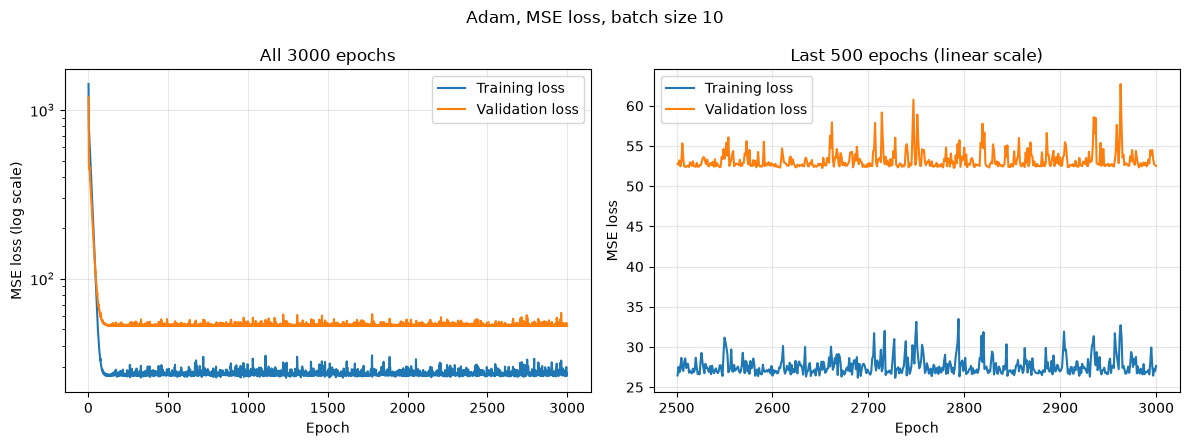

final training loss: 27.6348
final validation loss: 52.5086


In [69]:
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(epochs, train_losses, label="Training loss")
ax1.plot(epochs, val_losses, label="Validation loss")
ax1.set_yscale("log")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE loss (log scale)")
ax1.set_title("All 3000 epochs")
ax1.legend()
ax1.grid(alpha=0.3)

zoom = 500
ax2.plot(list(epochs)[-zoom:], train_losses[-zoom:], label="Training loss")
ax2.plot(list(epochs)[-zoom:], val_losses[-zoom:], label="Validation loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MSE loss")
ax2.set_title(f"Last {zoom} epochs (linear scale)")
ax2.legend()
ax2.grid(alpha=0.3)

fig.suptitle("Adam, MSE loss, batch size 10")
fig.tight_layout()
plt.show()

print(f"final training loss: {train_losses[-1]:.4f}")
print(f"final validation loss: {val_losses[-1]:.4f}")

**The prediction curve**

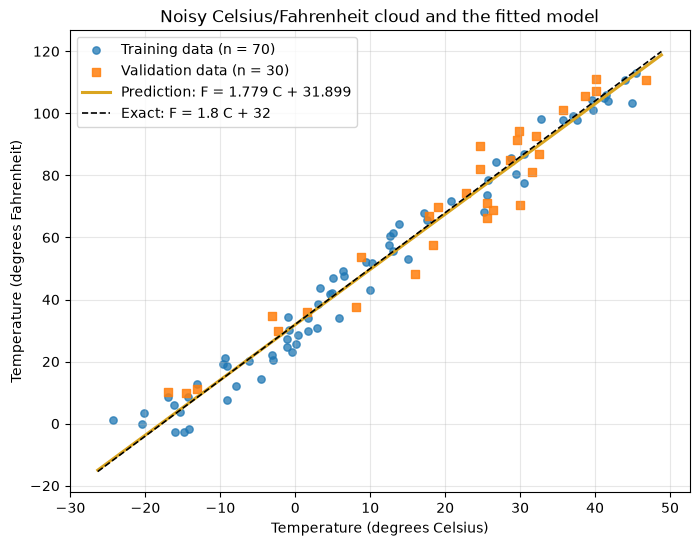

In [70]:
# A dense line of Celsius values spanning the data, for drawing the model prediction
c_line = torch.linspace(t_c.min().item() - 2, t_c.max().item() + 2, 200)
with torch.no_grad():
    f_line = model(c_line, *params)

plt.figure(figsize=(8, 6))
plt.scatter(train_x.squeeze(), train_y.squeeze(), s=28, alpha=0.75,
            label=f"Training data (n = {n_train})")
plt.scatter(val_x.squeeze(), val_y.squeeze(), s=36, alpha=0.85, marker="s",
            label=f"Validation data (n = {n_val})")
plt.plot(c_line, f_line, color="goldenrod", linewidth=2.2,
         label=f"Prediction: F = {w:.3f} C + {b:.3f}")
plt.plot(c_line, c_line * 9 / 5 + 32, color="black", linestyle="--", linewidth=1.2,
         label="Exact: F = 1.8 C + 32")

plt.xlabel("Temperature (degrees Celsius)")
plt.ylabel("Temperature (degrees Fahrenheit)")
plt.title("Noisy Celsius/Fahrenheit cloud and the fitted model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### The results

The losses decrease dramatically over the first few hundred epochs and then flatten out. They do not go to zero though. This makes sense since noise of standard deviation 3 was added to both columns, so even a perfect line leaves a residual variance.

The validation loss stays close to the training loss and keeps decreasing alongside it. I don't see evidence of overfitting. The training curve does sit slightly below the validation curve (although with this small of a sample, perhaps that's just from samplling noise).

The predicted slope is slightly less than the exact 1.8. 
